In [ ]:
# Importation des bibliothèques nécessaires
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
# Chargement des données MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Ensemble d'entraînement :", X_train.shape)
print("Ensemble de test :", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Ensemble d'entraînement : (60000, 28, 28)
Ensemble de test : (10000, 28, 28)


In [ ]:
# normalisation des données en les mettant à l'échelle entre 0 et 1
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [ ]:
# encodage des étiquettes en one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

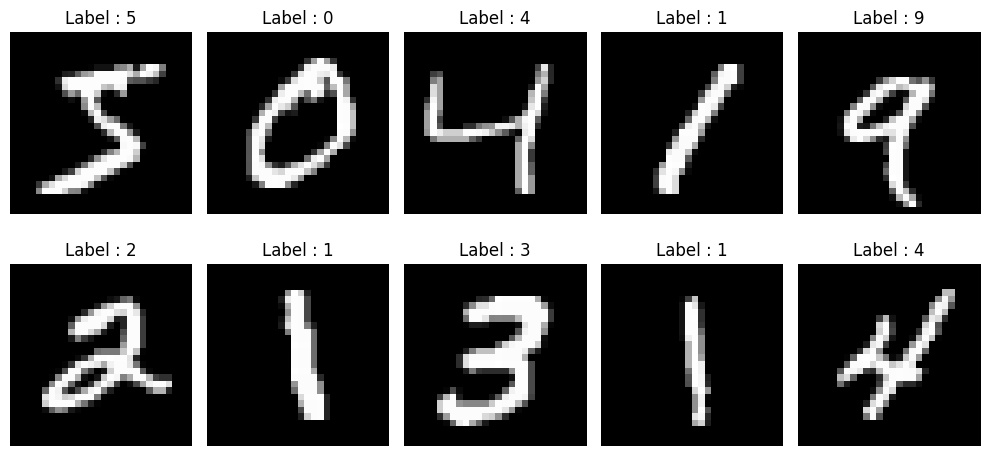

In [ ]:
# affichage de quelques exemples d'images du dataset
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label : {y_train[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Construction du modèle de réseau de neurones 
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

c:\Users\HP 840 G3\DAILYCHALLENGES\venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
# Compilation du modèle
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Résumé du modèle
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Entraînement du modèle
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9197 - loss: 0.2749 - val_accuracy: 0.9545 - val_loss: 0.1563
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9644 - loss: 0.1190 - val_accuracy: 0.9644 - val_loss: 0.1128
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9737 - loss: 0.0827 - val_accuracy: 0.9657 - val_loss: 0.1113
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9805 - loss: 0.0619 - val_accuracy: 0.9727 - val_loss: 0.0906
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9847 - loss: 0.0473 - val_accuracy: 0.9753 - val_loss: 0.0858
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9886 - loss: 0.0374 - val_accuracy: 0.9756 - val_loss: 0.0916
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9899 - loss: 0.0307 - val_accuracy: 0.9640 - val_loss: 0.1381
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9915 - loss: 0.0268

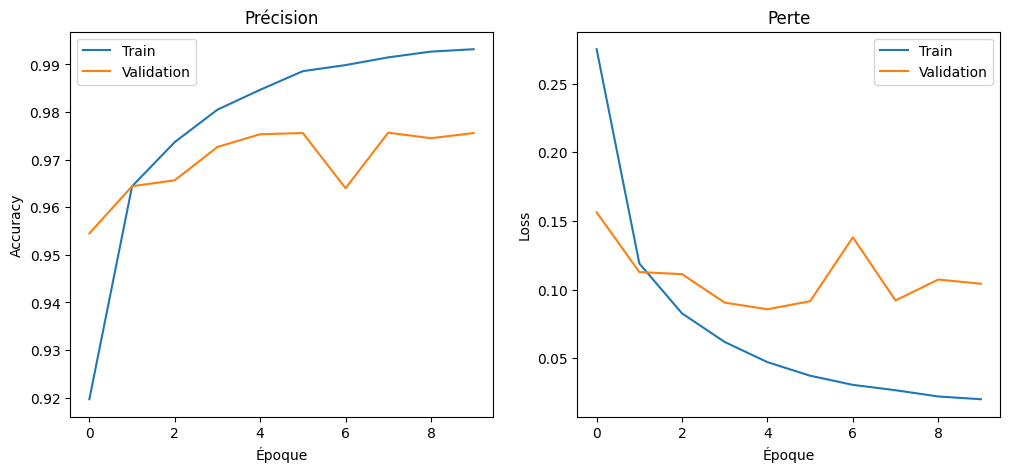

In [13]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Précision")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Perte")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [14]:
# Évaluation du modèle sur l'ensemble de test
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print(f"Précision sur le test : {test_accuracy:.4f}")

Précision sur le test : 0.9777


In [15]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


<Figure size 800x800 with 0 Axes>

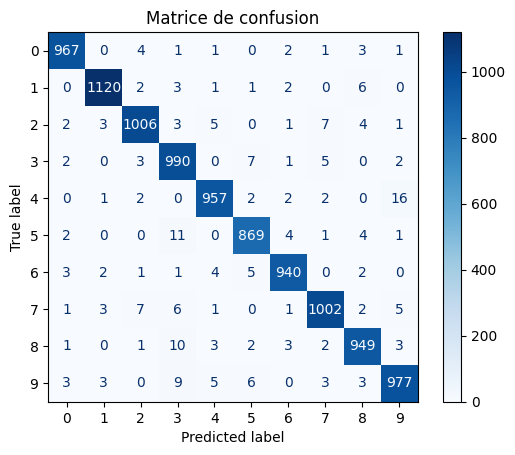

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=np.arange(10)
)

plt.figure(figsize=(8,8))
disp.plot(cmap='Blues')
plt.title("Matrice de confusion")
plt.show()

In [17]:
# identification des chifres avec lesquels le modèle a le plus de difficultés
erreurs = cm.sum(axis=1) - np.diag(cm)

for chiffre, nb_erreurs in enumerate(erreurs):
    print(f"Chiffre {chiffre} : {nb_erreurs} erreurs")

Chiffre 0 : 13 erreurs
Chiffre 1 : 15 erreurs
Chiffre 2 : 26 erreurs
Chiffre 3 : 20 erreurs
Chiffre 4 : 25 erreurs
Chiffre 5 : 23 erreurs
Chiffre 6 : 18 erreurs
Chiffre 7 : 26 erreurs
Chiffre 8 : 25 erreurs
Chiffre 9 : 32 erreurs
